<a href="https://colab.research.google.com/github/silbertdominique-arch/quantitative-finance-lab/blob/main/Day_2_Moving_Averages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np

prices = np.array([100, 105, 110, 108, 115])

print(prices.mean())
print(prices.max())
print(prices.min())

107.6
115
100


In [10]:
import pandas as pd

data = {
    "Date": ["Jan 1", "Jan 2", "Jan 3"],
    "Close": [103, 107, 109]
}

df = pd.DataFrame(data)

df["Close"]

,Close
0,103
1,107
2,109


In [16]:
import pandas as pd

data = {
    "Company": ["Apple", "Microsoft", "Nvidia", "Amazon"],
    "Price": [200, 400, 180, 220]
}

stocks = pd.DataFrame(data)

print(stocks)

print(stocks["Price"] .mean())

stocks[stocks["Price"] > 200]


stocks[stocks["Company"] == "Nvidia"]

stocks.iloc[0]

     Company  Price
0      Apple    200
1  Microsoft    400
2     Nvidia    180
3     Amazon    220
250.0


,0
Company,Apple
Price,200


[*********************100%***********************]  1 of 1 completed


BUY SIGNALS
Price            Close      SMA_50     SMA_200
Ticker            AAPL                        
Date                                          
2020-10-15  116.984627  113.310528   85.649377
2022-09-26  147.880768  157.087761  157.051099
2023-03-22  155.299026  145.312249  145.086297
2024-06-13  212.217087  180.642089  180.156914
2025-09-15  235.828857  220.653869  220.285788

SELL SIGNALS
Price            Close      SMA_50     SMA_200
Ticker            AAPL                        
Date                                          
2022-06-03  142.396240  155.680035  155.832538
2022-10-07  137.405411  155.624808  155.774530
2024-03-14  171.134354  181.416179  181.471427
2025-04-07  180.350723  226.748032  227.076332


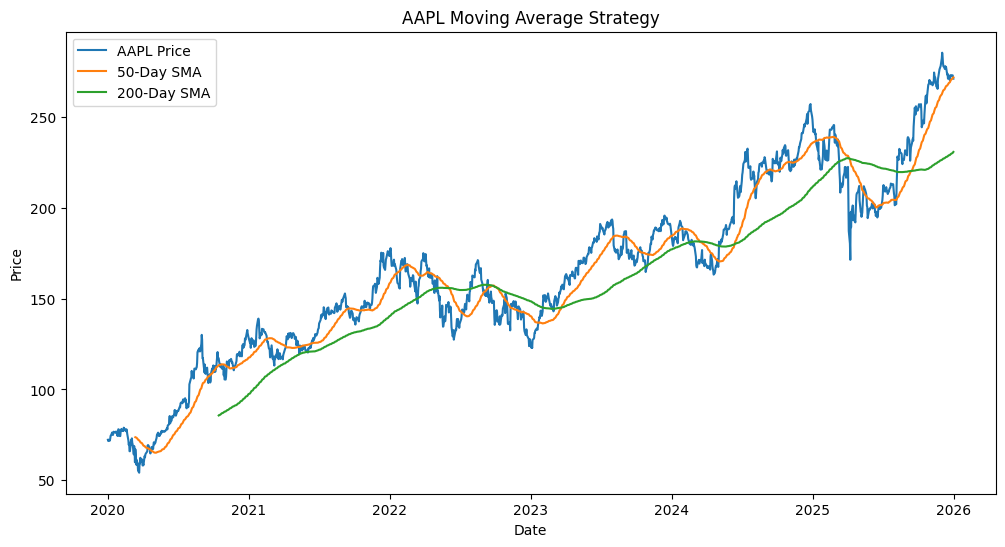

In [21]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np




apple = yf.download("AAPL", start="2020-01-01", end="2026-01-01", auto_adjust=True)

apple.head()



apple["SMA_50"] = apple["Close"].rolling(window=50).mean()
apple["SMA_200"] = apple["Close"].rolling(window=200).mean()


apple["Signal"] = np.where(
    apple["SMA_50"] > apple["SMA_200"],
    1,
    0
)

apple["Position"] = apple["Signal"].diff()





buy_signals = apple[apple["Position"] == 1]

sell_signals = apple[apple["Position"] == -1]





print("BUY SIGNALS")
print(buy_signals[["Close", "SMA_50", "SMA_200"]])

print("\nSELL SIGNALS")
print(sell_signals[["Close", "SMA_50", "SMA_200"]])








import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(apple.index, apple["Close"], label="AAPL Price")
plt.plot(apple.index, apple["SMA_50"], label="50-Day SMA")
plt.plot(apple.index, apple["SMA_200"], label="200-Day SMA")

plt.title("AAPL Moving Average Strategy")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

Overwriting 02_moving_averages.py
